# Penguins 9.16

### Import

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

### Define functions

In [18]:
def simulate_linear_regression_prior(X, n_prior_samples=10000, n_chains=4, random_seed=42):
    """
    Simulate from the prior predictive distribution of a Normal linear regression model.
    
    Parameters:
    -----------
    X : array-like
        Predictor variable values (culmen length)
    n_prior_samples : int
        Number of prior samples to draw per chain
    n_chains : int
        Number of chains (for compatibility with R's stan_glm)
    random_seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    dict with keys:
        - 'beta_0': Intercept samples (n_chains * n_prior_samples,)
        - 'beta_1': Slope samples
        - 'sigma': Residual SD samples
        - 'y_sim': Simulated Y values (n_chains * n_prior_samples, len(X))
    """
    np.random.seed(random_seed)
    
    total_samples = n_chains * n_prior_samples
    
    # Sample from priors
    beta_0_samples = np.random.normal(200, 50, total_samples)
    beta_1_samples = np.random.normal(0, 10, total_samples)
    
    # HalfNormal: take absolute value of Normal(0, 10)
    sigma_samples = np.abs(np.random.normal(0, 10, total_samples))
    
    # Simulate Y values from prior predictive
    y_sim = np.zeros((total_samples, len(X)))
    for i in range(total_samples):
        mu = beta_0_samples[i] + beta_1_samples[i] * X
        y_sim[i, :] = np.random.normal(mu, sigma_samples[i], len(X))
    
    # Reshape to chains format (n_chains, n_prior_samples, ...)
    beta_0_by_chain = beta_0_samples.reshape(n_chains, n_prior_samples)
    beta_1_by_chain = beta_1_samples.reshape(n_chains, n_prior_samples)
    sigma_by_chain = sigma_samples.reshape(n_chains, n_prior_samples)
    y_sim_by_chain = y_sim.reshape(n_chains, n_prior_samples, len(X))
    
    return {
        'beta_0': beta_0_samples,
        'beta_1': beta_1_samples,
        'sigma': sigma_samples,
        'y_sim': y_sim,
        'beta_0_by_chain': beta_0_by_chain,
        'beta_1_by_chain': beta_1_by_chain,
        'sigma_by_chain': sigma_by_chain,
        'y_sim_by_chain': y_sim_by_chain,
        'n_chains': n_chains,
        'n_samples': n_prior_samples,
        'total_samples': total_samples
    }

def prior_summary(prior_samples_dict):
    """
    Print summary statistics of prior samples (like R's prior_summary).
    """
    beta_0 = prior_samples_dict['beta_0']
    beta_1 = prior_samples_dict['beta_1']
    sigma = prior_samples_dict['sigma']
    
    print("Prior Summary Statistics:")
    print("-" * 50)
    
    print(f"\nβ₀ (Intercept):")
    print(f"  Prior: N(200, 50²)")
    print(f"  Mean: {beta_0.mean():.2f}")
    print(f"  SD:   {beta_0.std():.2f}")
    print(f"  2.5%: {np.percentile(beta_0, 2.5):.1f}")
    print(f"  97.5%: {np.percentile(beta_0, 97.5):.1f}")
    
    print(f"\nβ₁ (Slope):")
    print(f"  Prior: N(0, 10²)")
    print(f"  Mean: {beta_1.mean():.4f}")
    print(f"  SD:   {beta_1.std():.4f}")
    print(f"  2.5%: {np.percentile(beta_1, 2.5):.2f}")
    print(f"  97.5%: {np.percentile(beta_1, 97.5):.2f}")
    
    print(f"\nσ (Residual SD):")
    print(f"  Prior: HalfNormal(10)")
    print(f"  Mean: {sigma.mean():.2f}")
    print(f"  SD:   {sigma.std():.2f}")
    print(f"  2.5%: {np.percentile(sigma, 2.5):.1f}")
    print(f"  97.5%: {np.percentile(sigma, 97.5):.1f}")

def plot_prior_lines(X, Y=None, prior_samples_dict=None, n_lines=100):
    """
    Plot prior plausible regression lines and simulated datasets.
    """
    if prior_samples_dict is None:
        prior_samples_dict = simulate_linear_regression_prior(X, n_prior_samples=1000)
    
    beta_0 = prior_samples_dict['beta_0']
    beta_1 = prior_samples_dict['beta_1']
    sigma = prior_samples_dict['sigma']
    y_sim = prior_samples_dict['y_sim']
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Subplot 1: Prior regression lines
    ax1 = axes[0]
    
    # Select random subset of samples for lines
    n_lines_actual = min(n_lines, len(beta_0))
    random_indices = np.random.choice(len(beta_0), n_lines_actual, replace=False)
    
    # Create grid for smooth lines
    X_grid = np.linspace(X.min() - 5, X.max() + 5, 100)
    
    for idx in random_indices:
        y_line = beta_0[idx] + beta_1[idx] * X_grid
        ax1.plot(X_grid, y_line, 'b-', alpha=0.1, linewidth=0.8)
    
    # Add observed data if provided
    if Y is not None:
        ax1.scatter(X, Y, c='red', alpha=0.3, s=10, label='Observed data')
    
    ax1.set_xlabel('Bill Length (mm)', fontsize=12)
    ax1.set_ylabel('Flipper Length (mm)', fontsize=12)
    ax1.set_title(f'{n_lines_actual} Prior Plausible Regression Lines\n(β₀ + β₁X)', fontsize=12)
    if Y is not None:
        ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Subplot 2: Simulated datasets
    ax2 = axes[1]
    
    n_datasets = 4
    dataset_indices = np.random.choice(len(beta_0), n_datasets, replace=False)
    
    for i, idx in enumerate(dataset_indices):
        color = plt.cm.viridis(i / n_datasets)
        Y_sim = y_sim[idx, :]
        ax2.scatter(X, Y_sim, c=[color], alpha=0.6, s=20, 
                   label=f'Dataset {i+1}', marker='o')
    
    ax2.set_xlabel('Bill Length (mm)', fontsize=12)
    ax2.set_ylabel('Flipper Length (mm)', fontsize=12)
    ax2.set_title('4 Datasets Simulated from Prior\n(Under Prior Predictive Distribution)', fontsize=12)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def load_penguins_data(path: str = None) -> pd.DataFrame|None:
    if path == None:
        print("Please enter a path")
        return None
    else:
        data = pd.read_csv(path)
        return data

### Load data

In [19]:
path = "../data/penguins_size.csv"
data = load_penguins_data(path).dropna()
X = data['culmen_length_mm'].values
Y = data['flipper_length_mm'].values

print(f"\nDataset summary:")
print(f"  Number of penguins: {len(data)}")
print(f"  Bill length range: [{X.min():.1f}, {X.max():.1f}] mm")
print(f"  Flipper length range: [{Y.min():.1f}, {Y.max():.1f}] mm")


Dataset summary:
  Number of penguins: 334
  Bill length range: [32.1, 59.6] mm
  Flipper length range: [172.0, 231.0] mm


### Simulate the posterior

In [20]:
print("\nSimulating from prior (4 chains, 10,000 iterations each)...")

# Simulate from prior
prior_samples = simulate_linear_regression_prior(
    X, 
    n_prior_samples=10000, 
    n_chains=4, 
    random_seed=42
)

print(f"\n✓ Successfully generated:")
print(f"  - {prior_samples['total_samples']:,} total prior samples")
print(f"  - {prior_samples['n_chains']} chains")
print(f"  - {prior_samples['n_samples']:,} draws per chain")


Simulating from prior (4 chains, 10,000 iterations each)...

✓ Successfully generated:
  - 40,000 total prior samples
  - 4 chains
  - 10,000 draws per chain


### Summary

In [21]:
prior_summary(prior_samples)

Prior Summary Statistics:
--------------------------------------------------

β₀ (Intercept):
  Prior: N(200, 50²)
  Mean: 199.89
  SD:   50.01
  2.5%: 102.0
  97.5%: 297.7

β₁ (Slope):
  Prior: N(0, 10²)
  Mean: 0.0458
  SD:   10.0239
  2.5%: -19.68
  97.5%: 19.65

σ (Residual SD):
  Prior: HalfNormal(10)
  Mean: 7.97
  SD:   6.04
  2.5%: 0.3
  97.5%: 22.5


### Visualization

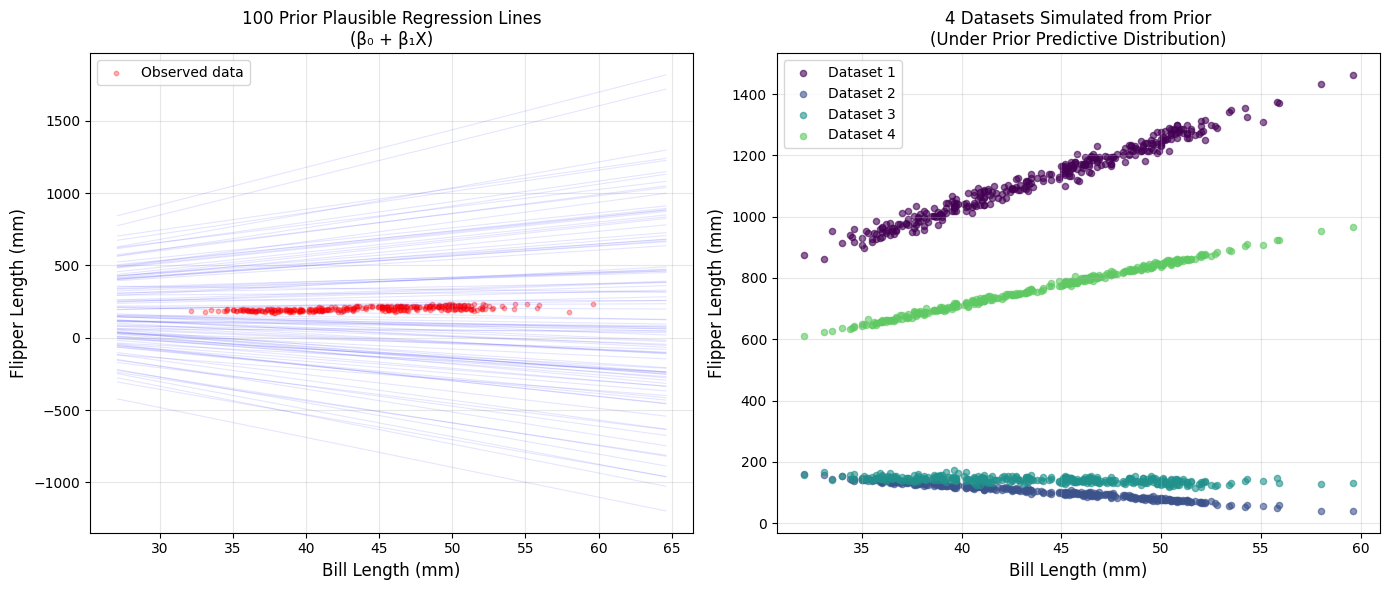

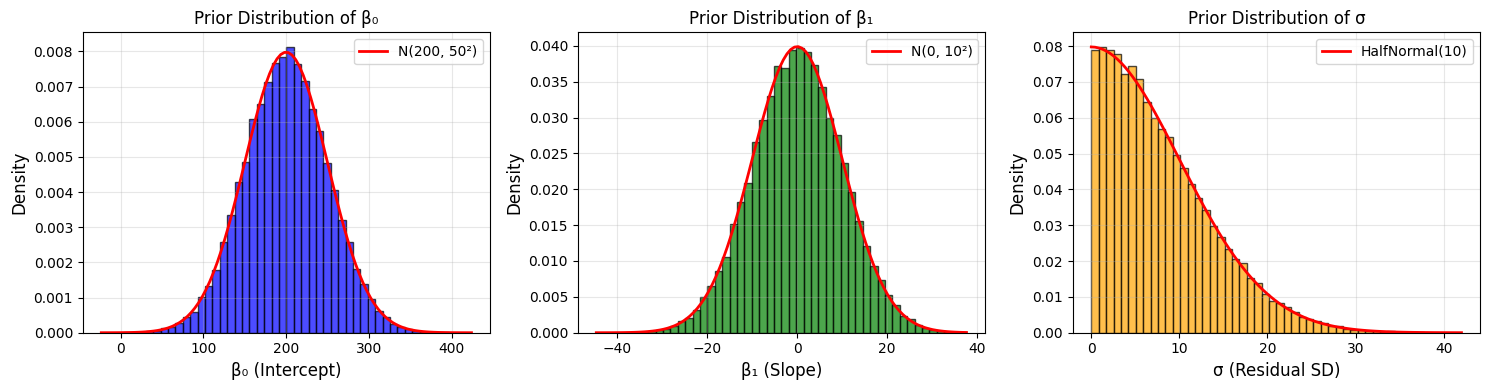

In [22]:
# Create the plots
fig = plot_prior_lines(X, Y, prior_samples, n_lines=100)

# Additional plots: Prior distributions of parameters
fig2, axes = plt.subplots(1, 3, figsize=(15, 4))

# Prior for β₀
ax = axes[0]
ax.hist(prior_samples['beta_0'], bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
x0 = np.linspace(prior_samples['beta_0'].min(), prior_samples['beta_0'].max(), 100)
ax.plot(x0, stats.norm.pdf(x0, 200, 50), 'r-', linewidth=2, label='N(200, 50²)')
ax.set_xlabel('β₀ (Intercept)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Prior Distribution of β₀')
ax.legend()
ax.grid(alpha=0.3)

# Prior for β₁
ax = axes[1]
ax.hist(prior_samples['beta_1'], bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
x1 = np.linspace(prior_samples['beta_1'].min(), prior_samples['beta_1'].max(), 100)
ax.plot(x1, stats.norm.pdf(x1, 0, 10), 'r-', linewidth=2, label='N(0, 10²)')
ax.set_xlabel('β₁ (Slope)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Prior Distribution of β₁')
ax.legend()
ax.grid(alpha=0.3)

# Prior for σ
ax = axes[2]
ax.hist(prior_samples['sigma'], bins=50, density=True, alpha=0.7, color='orange', edgecolor='black')
x_sigma = np.linspace(0, prior_samples['sigma'].max(), 100)
halfnorm_pdf = 2 * stats.norm.pdf(x_sigma, 0, 10)
ax.plot(x_sigma, halfnorm_pdf, 'r-', linewidth=2, label='HalfNormal(10)')
ax.set_xlabel('σ (Residual SD)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Prior Distribution of σ')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Summary

In [23]:
summary_table = pd.DataFrame({
    'Parameter': ['β₀', 'β₁', 'σ'],
    'Prior Distribution': ['Normal(200, 50²)', 'Normal(0, 10²)', 'HalfNormal(10)'],
    'Prior Mean': [prior_samples['beta_0'].mean(), 
                   prior_samples['beta_1'].mean(), 
                   prior_samples['sigma'].mean()],
    'Prior SD': [prior_samples['beta_0'].std(), 
                 prior_samples['beta_1'].std(), 
                 prior_samples['sigma'].std()],
    '2.5%': [np.percentile(prior_samples['beta_0'], 2.5),
              np.percentile(prior_samples['beta_1'], 2.5),
              np.percentile(prior_samples['sigma'], 2.5)],
    '97.5%': [np.percentile(prior_samples['beta_0'], 97.5),
               np.percentile(prior_samples['beta_1'], 97.5),
               np.percentile(prior_samples['sigma'], 97.5)]
})

print("\nPrior Summary Table:")
print(summary_table.round(2).to_string(index=False))


Prior Summary Table:
Parameter Prior Distribution  Prior Mean  Prior SD   2.5%  97.5%
       β₀   Normal(200, 50²)      199.89     50.01 101.96 297.73
       β₁     Normal(0, 10²)        0.05     10.02 -19.68  19.65
        σ     HalfNormal(10)        7.97      6.04   0.31  22.53


# Penguins 9.17

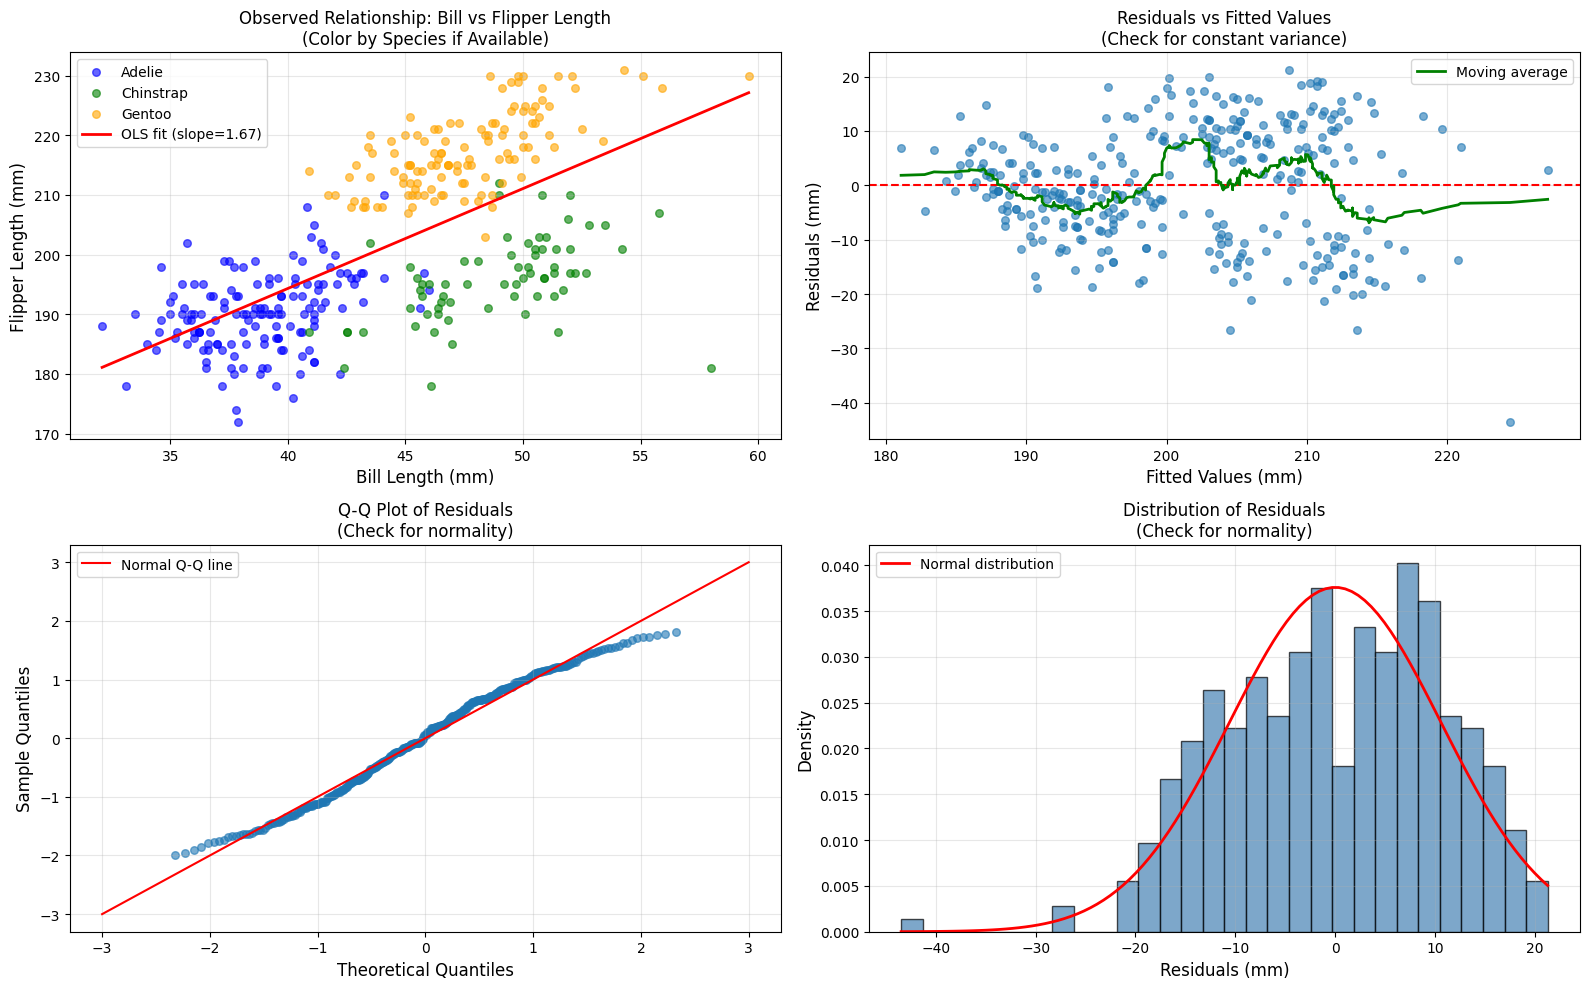

In [24]:
species = data['species'].values

fig = plt.figure(figsize=(16, 10))

# Subplot 1: Basic scatter plot with overall regression
ax1 = plt.subplot(2, 2, 1)

# Color by species
unique_species = np.unique(species)
colors = {'Adelie': 'blue', 'Chinstrap': 'green', 'Gentoo': 'orange'}
for sp in unique_species:
    mask = species == sp
    ax1.scatter(X[mask], Y[mask], alpha=0.6, s=30, label=sp, color=colors.get(sp, 'gray'))

# Add overall regression line
slope, intercept = np.polyfit(X, Y, 1)
x_range = np.array([X.min(), X.max()])
ax1.plot(x_range, intercept + slope * x_range, 'r-', linewidth=2, label=f'OLS fit (slope={slope:.2f})')

ax1.set_xlabel('Bill Length (mm)', fontsize=12)
ax1.set_ylabel('Flipper Length (mm)', fontsize=12)
ax1.set_title('Observed Relationship: Bill vs Flipper Length\n(Color by Species if Available)', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Residuals vs Fitted
ax2 = plt.subplot(2, 2, 2)

# Calculate residuals from linear fit
fitted = intercept + slope * X
residuals = Y - fitted

ax2.scatter(fitted, residuals, alpha=0.6, s=30)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Fitted Values (mm)', fontsize=12)
ax2.set_ylabel('Residuals (mm)', fontsize=12)
ax2.set_title('Residuals vs Fitted Values\n(Check for constant variance)', fontsize=12)
ax2.grid(alpha=0.3)

# Simple moving average to check pattern
order = np.argsort(fitted)
fitted_sorted = fitted[order]
residuals_sorted = residuals[order]
window = 30
smoothed = np.convolve(residuals_sorted, np.ones(window)/window, mode='same')
ax2.plot(fitted_sorted, smoothed, 'g-', linewidth=2, label='Moving average')
ax2.legend()

# Subplot 3: Q-Q plot for normality
ax3 = plt.subplot(2, 2, 3)

# Standardized residuals
std_residuals = (residuals - residuals.mean()) / residuals.std()
# Theoretical quantiles from normal distribution
theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, len(std_residuals)))
sample_quantiles = np.percentile(std_residuals, np.linspace(1, 99, len(std_residuals)))

ax3.scatter(theoretical_quantiles, sample_quantiles, alpha=0.6, s=30)
ax3.plot([-3, 3], [-3, 3], 'r-', linewidth=1.5, label='Normal Q-Q line')
ax3.set_xlabel('Theoretical Quantiles', fontsize=12)
ax3.set_ylabel('Sample Quantiles', fontsize=12)
ax3.set_title('Q-Q Plot of Residuals\n(Check for normality)', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)

# Subplot 4: Histogram of residuals
ax4 = plt.subplot(2, 2, 4)

ax4.hist(residuals, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
# Overlay normal distribution
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
ax4.plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()), 
         'r-', linewidth=2, label='Normal distribution')
ax4.set_xlabel('Residuals (mm)', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Distribution of Residuals\n(Check for normality)', fontsize=12)
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Is a normal regression fitting for this problem?

Looking at the first scatterplot we see a somewhat fitting regression, although it is clear that a regression from species to species might have been better seeing as how they cluster very much depending on species.

It seems that even though the penguins deviate significantly from species to species, a normal regression did the job for this case. By looking at the fourth barplot, the residual (actual value - fitted line) is in a range of -20 mm to 20 mm, which might or might not be a lot. Considering that the distribution is centered on 0, indication little to no bias.

### Summary

The normal regression seems to be fitting for this problem but a regression for each species might have produced better fitted lines.